# Binary Prediction on Spaceship Titanic Dataset

**Group 6**: Refer to the main report for group members information

## Section 0: Environment Preparation

In [2]:
!pip install kaggle kagglehub scikit-learn seaborn matplotlib pandas numpy imblearn lightgbm xgboost catboost

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            roc_curve, auc, precision_recall_curve)
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

## Section 1: Data Loading and Basic EDA

In [ ]:
# Define the path to your data
data_path = './spaceship-titanic'

try:
    # Load the data
    df_train = pd.read_csv(os.path.join(data_path, 'train.csv'))
    df_test = pd.read_csv(os.path.join(data_path, 'test.csv'))
    sample_submission_df = pd.read_csv(os.path.join(data_path, 'sample_submission.csv'))

    print("Data loaded successfully from Google Drive.")
    print(f"Train shape: {df_train.shape}")
    print(f"Test shape: {df_test.shape}")

    # Display preview
    display(df_train.head())
    display(df_train.info())
except FileNotFoundError:
    print(f"Error: Files not found at {data_path}.")
    print("Please check the folder path and ensure train.csv, test.csv, and sample_submission.csv are present.")
except Exception as e:
    print(f"An error occurred: {e}")

Data loaded successfully from Google Drive.
Train shape: (8693, 14)
Test shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


None

In [5]:
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nTrain shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
print(f"\nData types:\n{df_train.dtypes}")
print(f"\nTarget distribution:")
print(df_train['Transported'].value_counts(normalize=True))

DATASET OVERVIEW

Train shape: (8693, 14)
Test shape: (4277, 13)

Data types:
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

Target distribution:
Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


## Section 2: EDA Visualizations

### Missing Values


EDA SECTION 1: MISSING VALUES ANALYSIS


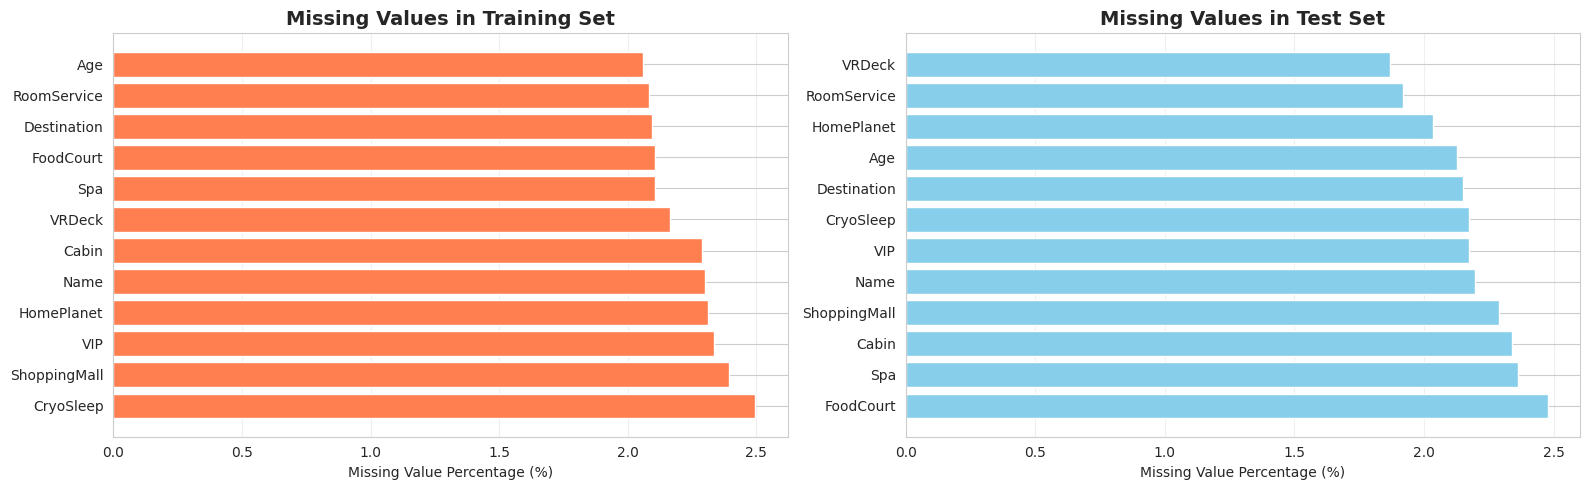


Missing Values Summary:
              Train Missing  Train %  Test Missing  Test %
CryoSleep               217     2.50          93.0    2.17
ShoppingMall            208     2.39          98.0    2.29
VIP                     203     2.34          93.0    2.17
HomePlanet              201     2.31          87.0    2.03
Name                    200     2.30          94.0    2.20
Cabin                   199     2.29         100.0    2.34
VRDeck                  188     2.16          80.0    1.87
FoodCourt               183     2.11         106.0    2.48
Spa                     183     2.11         101.0    2.36
Destination             182     2.09          92.0    2.15
RoomService             181     2.08          82.0    1.92
Age                     179     2.06          91.0    2.13


In [ ]:
print("\n" + "=" * 80)
print("EDA SECTION 1: MISSING VALUES ANALYSIS")
print("=" * 80)

# Missing values heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Train set missing values
missing_train = df_train.isnull().sum().sort_values(ascending=False)
missing_train_pct = (missing_train / len(df_train) * 100)

axes[0].barh(missing_train[missing_train > 0].index, missing_train_pct[missing_train > 0], color='coral')
axes[0].set_xlabel('Missing Value Percentage (%)')
axes[0].set_title('Missing Values in Training Set', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Test set missing values
missing_test = df_test.isnull().sum().sort_values(ascending=False)
missing_test_pct = (missing_test / len(df_test) * 100)

axes[1].barh(missing_test[missing_test > 0].index, missing_test_pct[missing_test > 0], color='skyblue')
axes[1].set_xlabel('Missing Value Percentage (%)')
axes[1].set_title('Missing Values in Test Set', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed missing values table
missing_data = pd.DataFrame({
    'Train Missing': df_train.isnull().sum(),
    'Train %': (df_train.isnull().sum() / len(df_train) * 100).round(2),
    'Test Missing': df_test.isnull().sum(),
    'Test %': (df_test.isnull().sum() / len(df_test) * 100).round(2)
})
missing_data = missing_data[missing_data['Train Missing'] + missing_data['Test Missing'] > 0].sort_values('Train Missing', ascending=False)

print("\nMissing Values Summary:")
print(missing_data)

### Feature Extraction

In [7]:
def extract_features(df):
    """Extract features from PassengerId and Cabin columns."""
    df = df.copy()

    df['Group'] = df['PassengerId'].str.split('_').str[0].astype(int)
    df['PNum'] = df['PassengerId'].str.split('_').str[1].astype(int)

    cabin_parts = df['Cabin'].str.split('/', expand=True)
    df['Deck'] = cabin_parts[0]
    df['CabNum'] = pd.to_numeric(cabin_parts[1], errors='coerce')
    df['Side'] = cabin_parts[2]

    df['Surname'] = df['Name'].str.split(' ').str[-1]

    return df

df_combined = pd.concat([df_train, df_test], ignore_index=True, sort=False)
df_combined = extract_features(df_combined)

### Target Distribution


EDA SECTION 2: TARGET DISTRIBUTION & KEY FEATURES


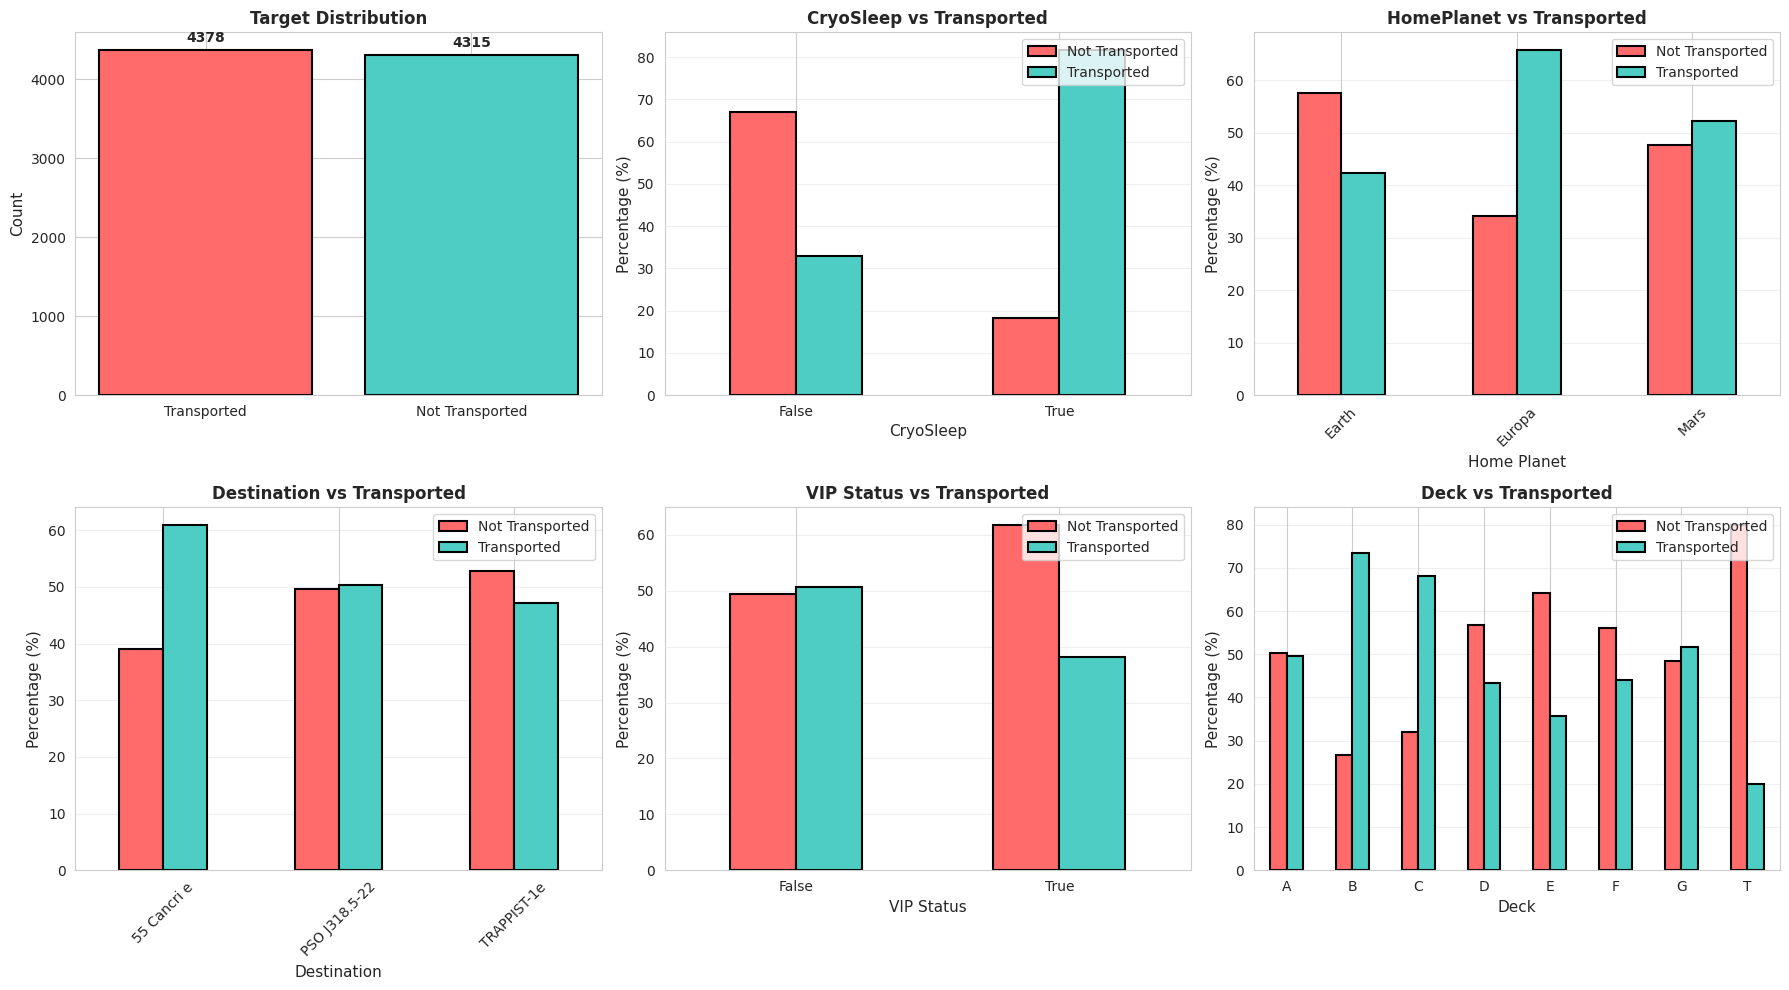

In [8]:
print("\n" + "=" * 80)
print("EDA SECTION 2: TARGET DISTRIBUTION & KEY FEATURES")
print("=" * 80)

# Fix: Create a temporary dataframe from df_combined that includes the target 'Transported'
# since df_combined contains the extracted 'Deck' feature
n_train = len(df_train)
df_train_viz = df_combined.iloc[:n_train].copy()
df_train_viz['Transported'] = df_train['Transported'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Target distribution
ax = axes[0, 0]
transported_counts = df_train_viz['Transported'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
ax.bar(transported_counts.index.map({False: 'Not Transported', True: 'Transported'}),
       transported_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Target Distribution', fontsize=12, fontweight='bold')
for i, v in enumerate(transported_counts.values):
    ax.text(i, v + 100, str(v), ha='center', fontweight='bold')

# 2. CryoSleep vs Transported
ax = axes[0, 1]
cryo_data = pd.crosstab(df_train_viz['CryoSleep'], df_train_viz['Transported'], normalize='index') * 100
cryo_data.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xlabel('CryoSleep', fontsize=11)
ax.set_title('CryoSleep vs Transported', fontsize=12, fontweight='bold')
ax.legend(['Not Transported', 'Transported'], loc='upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.3)

# 3. HomePlanet vs Transported
ax = axes[0, 2]
planet_data = pd.crosstab(df_train_viz['HomePlanet'], df_train_viz['Transported'], normalize='index') * 100
planet_data.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xlabel('Home Planet', fontsize=11)
ax.set_title('HomePlanet vs Transported', fontsize=12, fontweight='bold')
ax.legend(['Not Transported', 'Transported'], loc='upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.grid(axis='y', alpha=0.3)

# 4. Destination vs Transported
ax = axes[1, 0]
dest_data = pd.crosstab(df_train_viz['Destination'], df_train_viz['Transported'], normalize='index') * 100
dest_data.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xlabel('Destination', fontsize=11)
ax.set_title('Destination vs Transported', fontsize=12, fontweight='bold')
ax.legend(['Not Transported', 'Transported'], loc='upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.grid(axis='y', alpha=0.3)

# 5. VIP vs Transported
ax = axes[1, 1]
vip_data = pd.crosstab(df_train_viz['VIP'], df_train_viz['Transported'], normalize='index') * 100
vip_data.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xlabel('VIP Status', fontsize=11)
ax.set_title('VIP Status vs Transported', fontsize=12, fontweight='bold')
ax.legend(['Not Transported', 'Transported'], loc='upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.3)

# 6. Deck vs Transported (Now using df_train_viz which HAS 'Deck')
ax = axes[1, 2]
deck_data = pd.crosstab(df_train_viz['Deck'], df_train_viz['Transported'], normalize='index') * 100
deck_data.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xlabel('Deck', fontsize=11)
ax.set_title('Deck vs Transported', fontsize=12, fontweight='bold')
ax.legend(['Not Transported', 'Transported'], loc='upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Spending Analysis


EDA SECTION 3: SPENDING FEATURES ANALYSIS


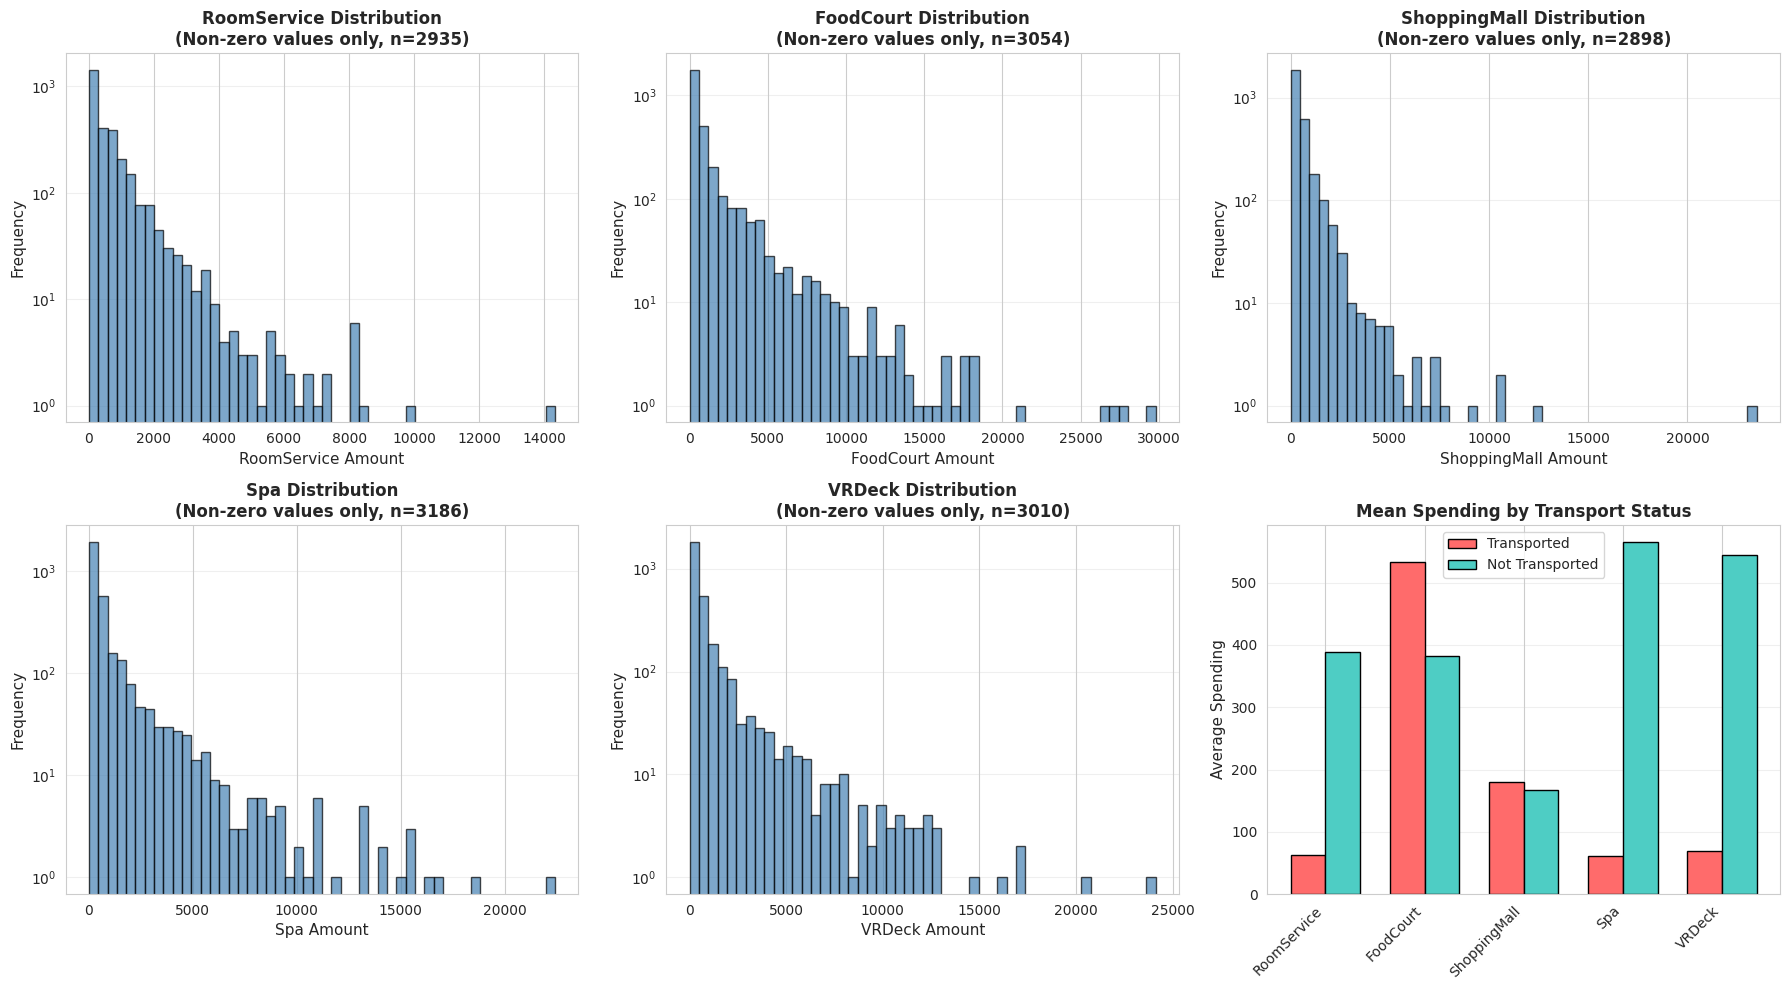

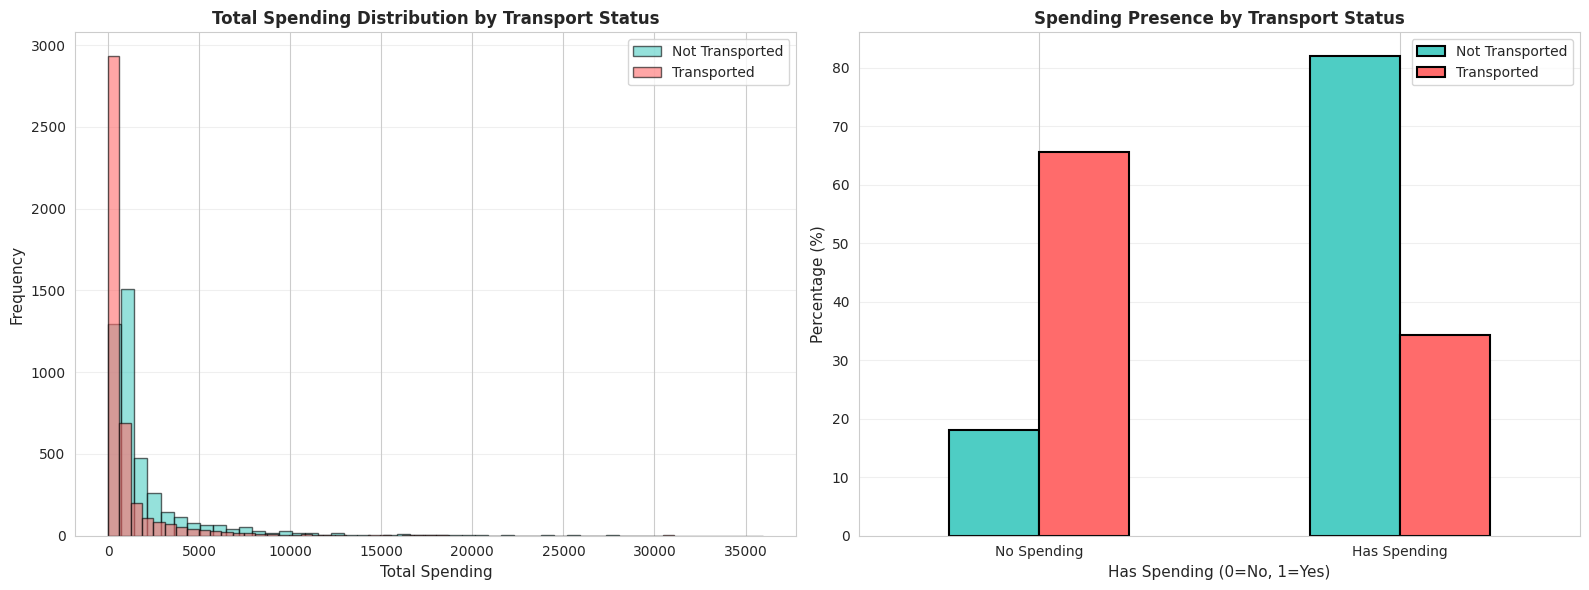

In [9]:
print("\n" + "=" * 80)
print("EDA SECTION 3: SPENDING FEATURES ANALYSIS")
print("=" * 80)

spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Distribution of each spending category (excluding zeros)
for idx, col in enumerate(spending_cols):
    ax = axes[idx // 3, idx % 3]

    non_zero = df_train[df_train[col] > 0][col]

    ax.hist(non_zero, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel(f'{col} Amount', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{col} Distribution\n(Non-zero values only, n={len(non_zero)})',
                fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

# Comparison of True vs False by spending
ax = axes[1, 2]
spending_by_transport = []
for col in spending_cols:
    true_mean = df_train[df_train['Transported'] == True][col].mean()
    false_mean = df_train[df_train['Transported'] == False][col].mean()
    spending_by_transport.append({'Spending': col, 'Transported': true_mean, 'Not Transported': false_mean})

spending_comp_df = pd.DataFrame(spending_by_transport)
x = np.arange(len(spending_cols))
width = 0.35

ax.bar(x - width/2, spending_comp_df['Transported'], width, label='Transported', color='#FF6B6B', edgecolor='black')
ax.bar(x + width/2, spending_comp_df['Not Transported'], width, label='Not Transported', color='#4ECDC4', edgecolor='black')
ax.set_ylabel('Average Spending', fontsize=11)
ax.set_title('Mean Spending by Transport Status', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(spending_cols, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Total spending analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate total spending
total_spend = df_train[spending_cols].sum(axis=1)

# Distribution by transported status
ax = axes[0]
ax.hist(total_spend[df_train['Transported'] == False], bins=50, alpha=0.6,
        label='Not Transported', color='#4ECDC4', edgecolor='black')
ax.hist(total_spend[df_train['Transported'] == True], bins=50, alpha=0.6,
        label='Transported', color='#FF6B6B', edgecolor='black')
ax.set_xlabel('Total Spending', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Total Spending Distribution by Transport Status', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Percentage with any spending
ax = axes[1]
has_spending = (total_spend > 0).astype(int)
spending_by_transport_bool = pd.crosstab(has_spending, df_train['Transported'], normalize='columns') * 100
spending_by_transport_bool.plot(kind='bar', ax=ax, color=['#4ECDC4', '#FF6B6B'], edgecolor='black', linewidth=1.5)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xlabel('Has Spending (0=No, 1=Yes)', fontsize=11)
ax.set_title('Spending Presence by Transport Status', fontsize=12, fontweight='bold')
ax.legend(['Not Transported', 'Transported'], loc='upper right')
ax.set_xticklabels(['No Spending', 'Has Spending'], rotation=0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Age Analysis


EDA SECTION 4: AGE ANALYSIS


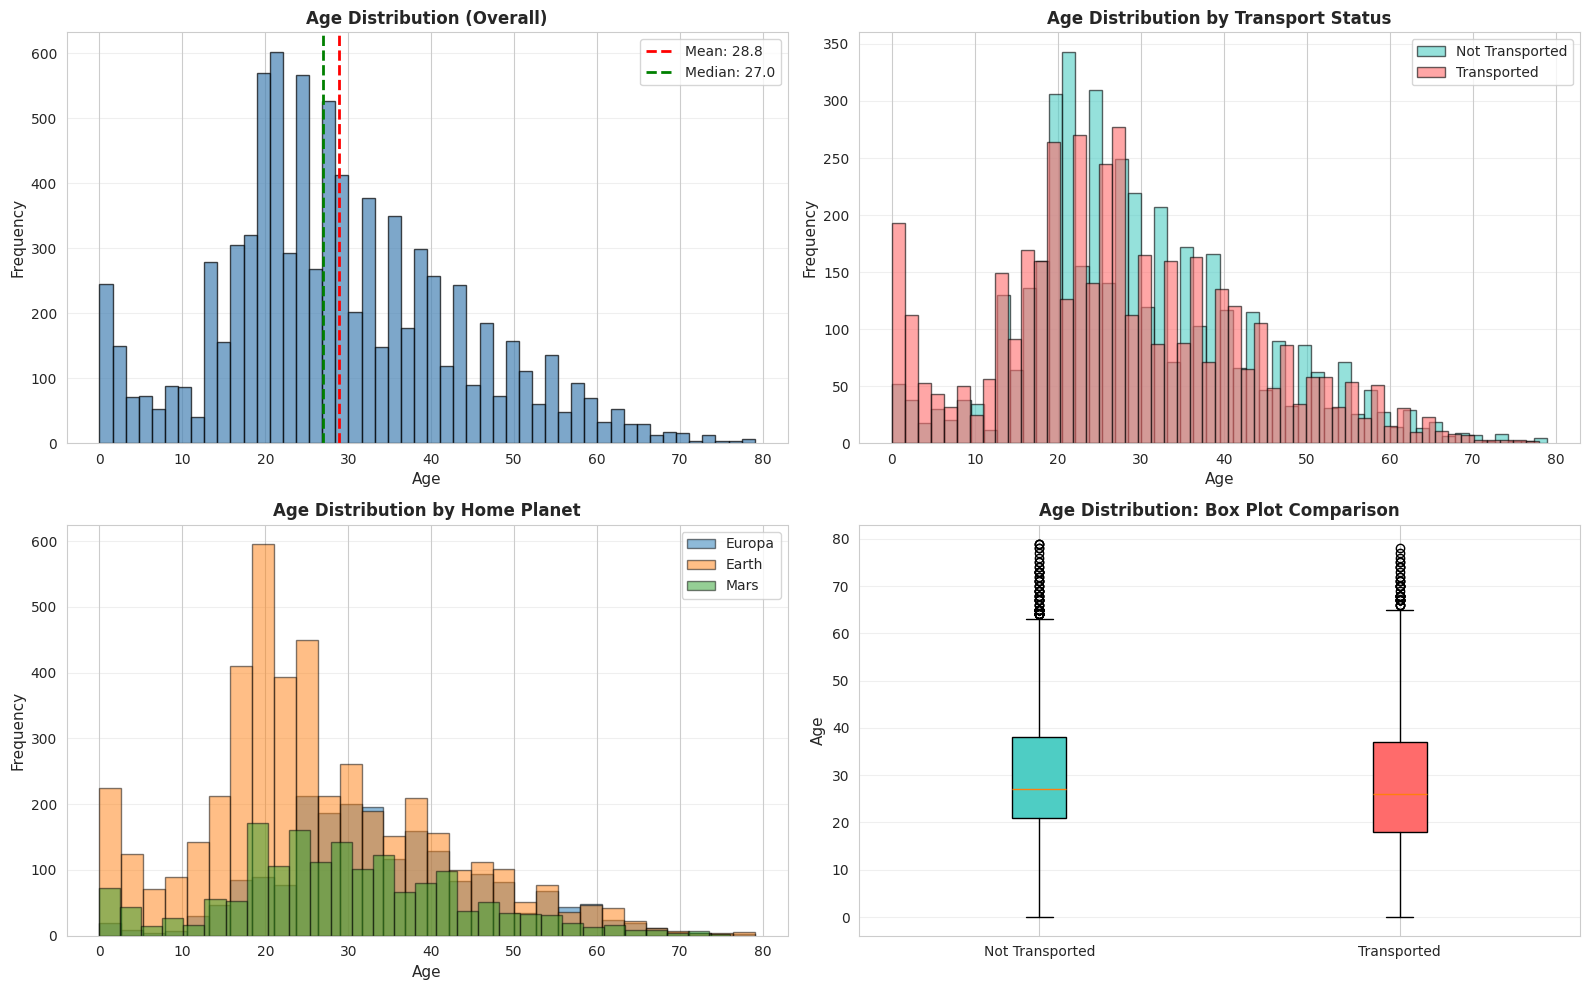

In [10]:
print("\n" + "=" * 80)
print("EDA SECTION 4: AGE ANALYSIS")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Age distribution overall
ax = axes[0, 0]
ax.hist(df_train['Age'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Age', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Age Distribution (Overall)', fontsize=12, fontweight='bold')
ax.axvline(df_train['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_train["Age"].mean():.1f}')
ax.axvline(df_train['Age'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_train["Age"].median():.1f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Age distribution by transported status
ax = axes[0, 1]
ax.hist(df_train[df_train['Transported'] == False]['Age'].dropna(), bins=50, alpha=0.6,
        label='Not Transported', color='#4ECDC4', edgecolor='black')
ax.hist(df_train[df_train['Transported'] == True]['Age'].dropna(), bins=50, alpha=0.6,
        label='Transported', color='#FF6B6B', edgecolor='black')
ax.set_xlabel('Age', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Age Distribution by Transport Status', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Age distribution by Home Planet
ax = axes[1, 0]
for planet in df_train['HomePlanet'].dropna().unique():
    planet_ages = df_train[df_train['HomePlanet'] == planet]['Age'].dropna()
    ax.hist(planet_ages, bins=30, alpha=0.5, label=planet, edgecolor='black')
ax.set_xlabel('Age', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Age Distribution by Home Planet', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Box plot: Age by transported status
ax = axes[1, 1]
data_box = [df_train[df_train['Transported'] == False]['Age'].dropna(),
            df_train[df_train['Transported'] == True]['Age'].dropna()]
bp = ax.boxplot(data_box, labels=['Not Transported', 'Transported'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#4ECDC4', '#FF6B6B']):
    patch.set_facecolor(color)
ax.set_ylabel('Age', fontsize=11)
ax.set_title('Age Distribution: Box Plot Comparison', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Data Preparation (Rule-based imputation + Feature Engineering)

In [11]:
def fill_by_group(df, group_col, target_col):
    """Fill missing values in target_col using mode of group_col."""
    mask = df[target_col].isna()
    df.loc[mask, target_col] = df.loc[mask, group_col].map(
        df.groupby(group_col)[target_col].apply(lambda x: x.mode()[0] if len(x.mode()) > 0 else None)
    )
    return df

def impute_rule_based(df):
    """Implement rule-based imputation strategy."""
    df = df.copy()

    for col in ['HomePlanet', 'Destination', 'Side', 'Deck']:
        df = fill_by_group(df, 'Group', col)

    df = fill_by_group(df, 'Surname', 'HomePlanet')

    deck_to_planet = {
        'A': 'Europa', 'B': 'Europa', 'C': 'Europa', 'T': 'Europa',
        'G': 'Earth', 'D': 'Mars'
    }
    mask = df['HomePlanet'].isna() & df['Deck'].isin(deck_to_planet)
    df.loc[mask, 'HomePlanet'] = df.loc[mask, 'Deck'].map(deck_to_planet)

    df['HomePlanet'] = df['HomePlanet'].fillna('Earth')
    df['Destination'] = df['Destination'].fillna('TRAPPIST-1e')

    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    has_spending = df[spending_cols].sum(axis=1) > 0
    df.loc[has_spending, 'CryoSleep'] = 'False'

    for col in spending_cols:
        cryo_true = df['CryoSleep'] == 'True'
        df.loc[cryo_true, col] = 0

    earth_or_child = (df['HomePlanet'] == 'Earth') | (df['Age'] < 18)
    df.loc[earth_or_child & df['VIP'].isna(), 'VIP'] = 'False'
    df['VIP'] = df['VIP'].fillna('False')

    for col in ['Age'] + spending_cols:
        median_per_planet = df.groupby('HomePlanet')[col].median()
        for planet in median_per_planet.index:
            mask = (df['HomePlanet'] == planet) & (df[col].isna())
            df.loc[mask, col] = median_per_planet[planet]

    df['Age'] = df['Age'].fillna(df['Age'].median())
    for col in spending_cols:
        df[col] = df[col].fillna(0)

    for col in ['Deck', 'Side']:
        df[col] = df[col].fillna(df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown')

    return df

def engineer_features(df):
    """Create advanced features."""
    df = df.copy()

    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    # Spending features
    df['TotalSpend'] = df[spending_cols].sum(axis=1)
    df['LogSpend'] = np.log1p(df['TotalSpend'])
    df['LuxurySpend'] = df['RoomService'] + df['Spa'] + df['VRDeck']
    df['BasicSpend'] = df['FoodCourt'] + df['ShoppingMall']
    df['LuxuryRatio'] = df['LuxurySpend'] / (df['TotalSpend'] + 1)
    df['BasicRatio'] = df['BasicSpend'] / (df['TotalSpend'] + 1)
    df['NumServicesUsed'] = (df[spending_cols] > 0).sum(axis=1)
    df['HasSpent'] = (df['TotalSpend'] > 0).astype(int)

    # Group features
    group_stats = df.groupby('Group').agg({
        'TotalSpend': ['sum', 'mean', 'std'],
        'CryoSleep': lambda x: (x == 'True').mean(),
        'Group': 'size'
    }).reset_index()

    group_stats.columns = ['Group', 'GroupTotalSpend', 'GroupMeanSpend', 'GroupStdSpend',
                          'GroupCryoRate', 'GroupSize']

    df = df.merge(group_stats, on='Group', how='left')

    df['SpendVsGroupMean'] = df['TotalSpend'] - df['GroupMeanSpend']
    df['IsAlone'] = (df['GroupSize'] == 1).astype(int)

    family_size = df.groupby('Surname').size().reset_index(name='FamilySize')
    df = df.merge(family_size, on='Surname', how='left')

    # Cabin features
    df['CabRegion'] = (df['CabNum'] // 300).fillna(-1).astype(int)
    df['CabNumBin'] = pd.cut(df['CabNum'], bins=10, labels=False).fillna(-1).astype(int)

    cabin_stats = df.groupby('Deck').agg({
        'TotalSpend': 'mean',
        'CryoSleep': lambda x: (x == 'True').mean(),
        'Cabin': 'count'
    }).reset_index()
    cabin_stats.columns = ['Deck', 'CabinMeanSpend', 'CabinCryoRate', 'CabinSize']

    df = df.merge(cabin_stats, on='Deck', how='left')
    df['DeckSide'] = df['Deck'] + df['Side']

    # Age features
    df['AgeBin'] = pd.cut(df['Age'],
                          bins=[0, 12, 18, 25, 35, 50, 100],
                          labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'MidAge', 'Senior'],
                          include_lowest=True)

    df['CryoChild'] = ((df['Age'] < 18) & (df['CryoSleep'] == 'True')).astype(int)
    df['CryoSpendConflict'] = ((df['CryoSleep'] == 'True') & (df['TotalSpend'] > 0)).astype(int)
    df['AgeSpendInteraction'] = df['Age'] * df['TotalSpend']

    return df

df_rule = impute_rule_based(df_combined)
df_engineered = engineer_features(df_rule)

print("\nData preprocessing complete!")
print(f"Total features created: {df_engineered.shape[1]}")


Data preprocessing complete!
Total features created: 46


### Correlation Analysis


EDA SECTION 5: CORRELATION ANALYSIS


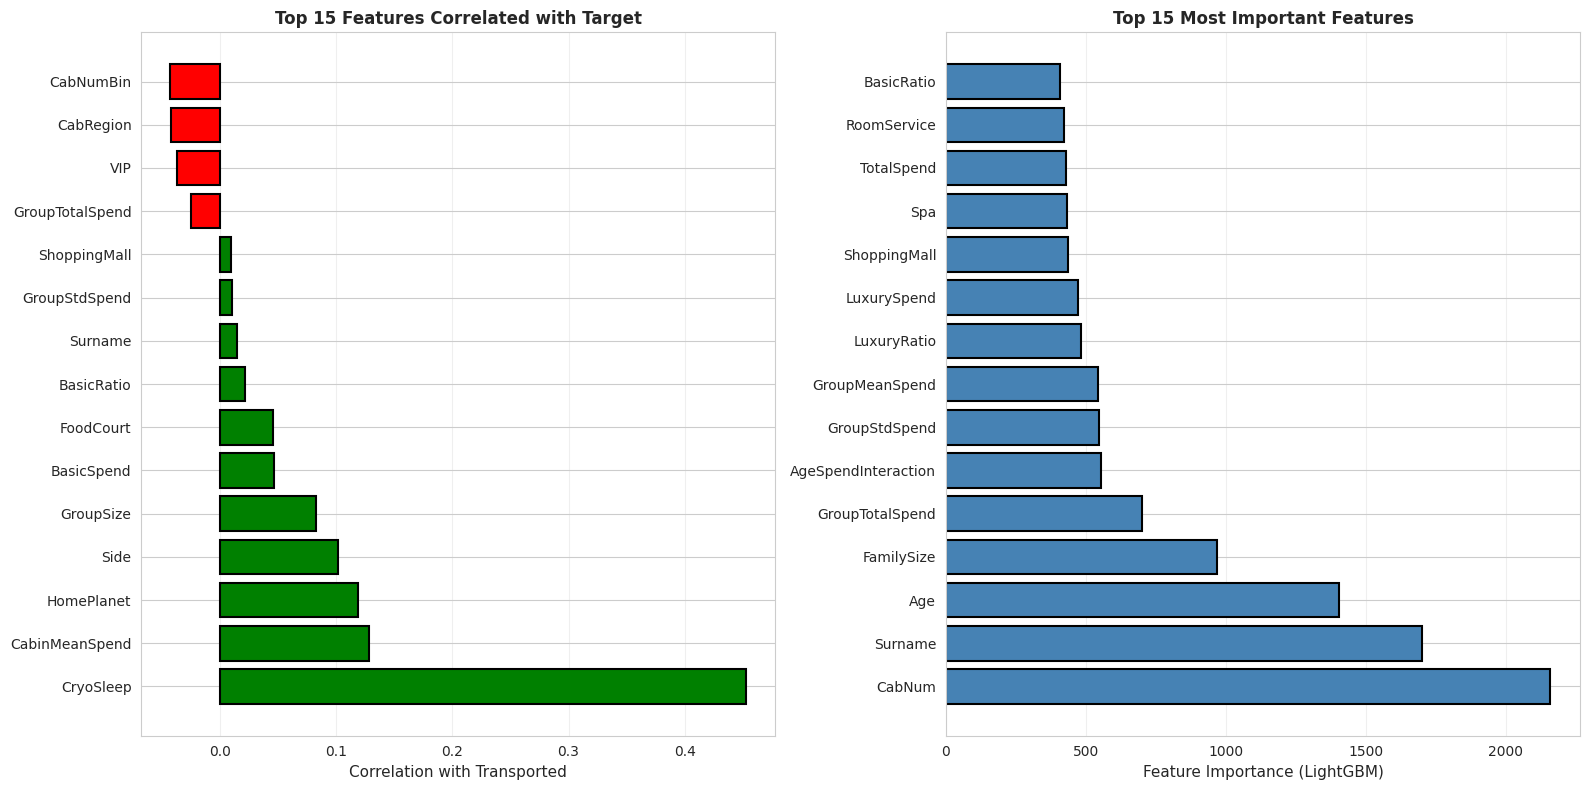

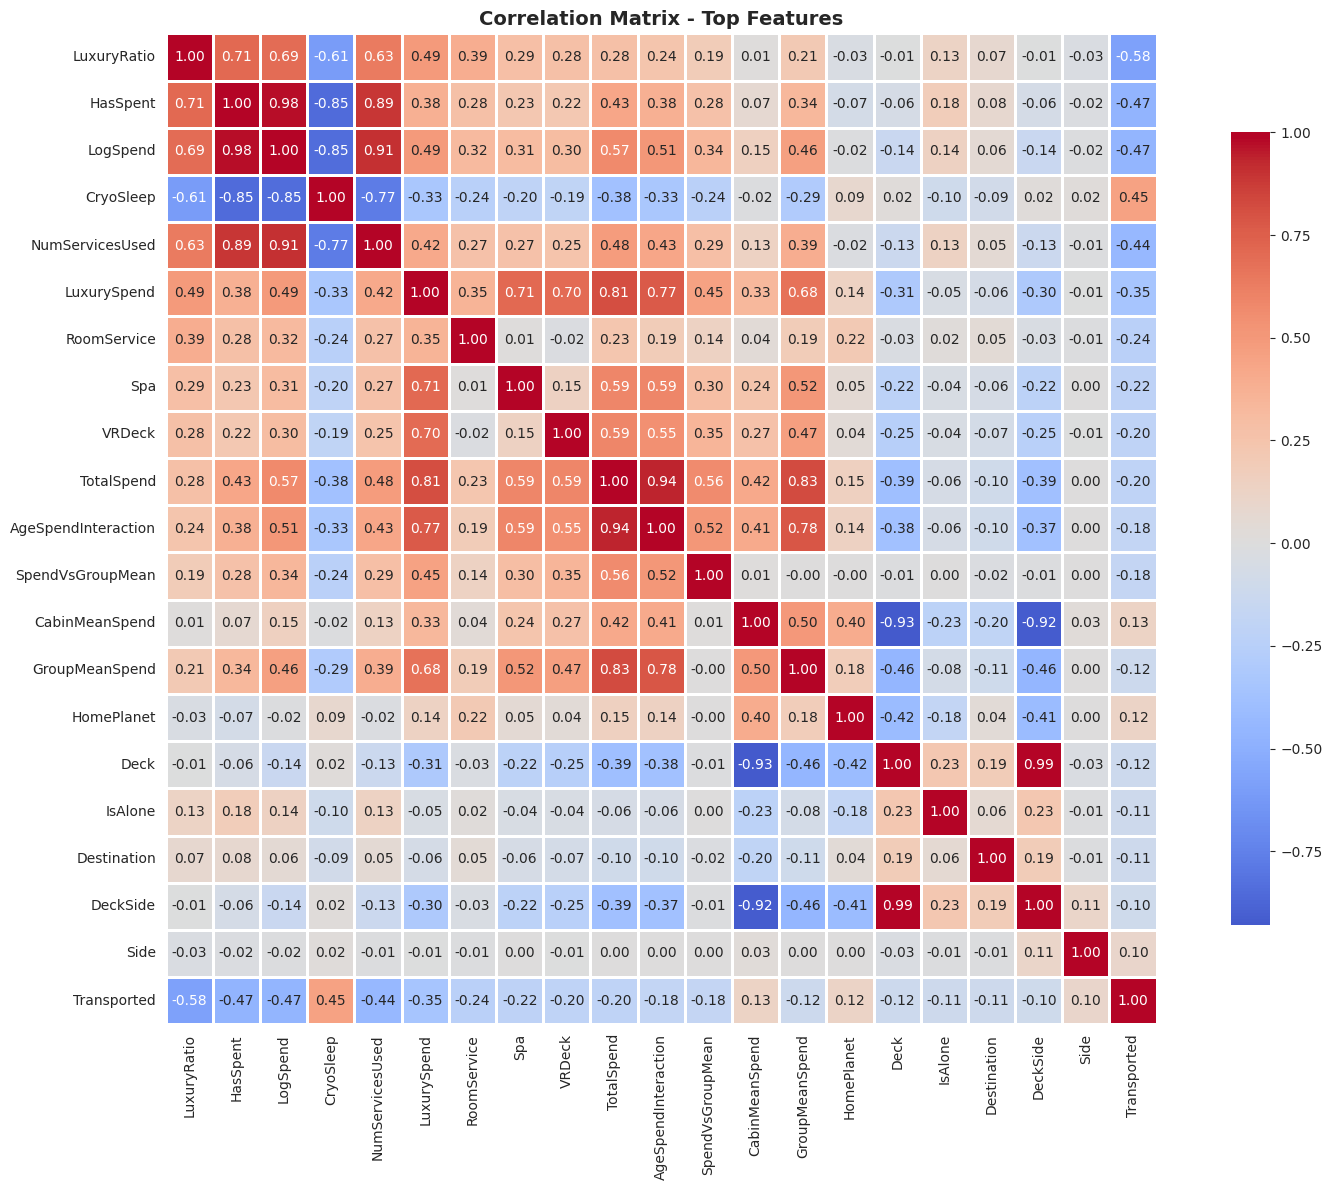

In [ ]:
print("\n" + "=" * 80)
print("EDA SECTION 5: CORRELATION ANALYSIS")
print("=" * 80)

# Prepare data for correlation
df_corr = df_engineered.copy()
n_train = len(df_train)

# Encode categorical for correlation
le_dict = {}
for col in df_corr.select_dtypes(include='object').columns:
    if col not in ['PassengerId', 'Cabin', 'Name']:
        le = LabelEncoder()
        df_corr[col] = le.fit_transform(df_corr[col].astype(str))
        le_dict[col] = le

# Select numeric features and ensure no duplicates
numeric_features = df_corr.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['Group', 'PNum', 'Transported']
numeric_features = [f for f in numeric_features if f not in exclude_cols]

# Calculate correlation with target
train_data = df_corr.iloc[:n_train].copy()
train_data['Transported'] = df_train['Transported'].astype(int)

corr_target = train_data[list(set(numeric_features + ['Transported']))].corr()['Transported']
correlation_with_target = corr_target.drop('Transported', errors='ignore').sort_values(ascending=False)

# Plot top correlations
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top positive correlations
ax = axes[0]
top_corr = correlation_with_target.head(15)
colors_corr = ['green' if x > 0 else 'red' for x in top_corr.values]
ax.barh(range(len(top_corr)), top_corr.values, color=colors_corr, edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index)
ax.set_xlabel('Correlation with Transported', fontsize=11)
ax.set_title('Top 15 Features Correlated with Target', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Feature importance from LightGBM
ax = axes[1]
X_temp = train_data[numeric_features].copy()
y_temp = train_data['Transported'].values

lgb_model = lgb.LGBMClassifier(n_estimators=500, random_state=42, verbose=-1)
lgb_model.fit(X_temp, y_temp)

feature_importance = pd.DataFrame({
    'feature': numeric_features,
    'importance': lgb_model.feature_importances_
}).sort_values(by='importance', ascending=False).head(15)

ax.barh(range(len(feature_importance)), feature_importance['importance'].values,
        color='steelblue', edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(feature_importance)))
ax.set_yticklabels(feature_importance['feature'].values)
ax.set_xlabel('Feature Importance (LightGBM)', fontsize=11)
ax.set_title('Top 15 Most Important Features', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(16, 12))
top_features = correlation_with_target.abs().sort_values(ascending=False).head(20).index.tolist() + ['Transported']
corr_matrix = train_data[top_features].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Top Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 3: Encoding and Data Preparation for Modeling

In [13]:
def prepare_data_for_modeling(df, encode=True):
    """Prepare data: encode categorical, handle missing, scale if needed."""
    df = df.copy()

    categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP',
                           'Deck', 'Side', 'Surname', 'AgeBin', 'DeckSide']
    numeric_features = [col for col in df.columns if df[col].dtype in [np.number]
                       and col not in ['Group', 'PNum']]

    if encode:
        label_encoders = {}
        for col in categorical_features:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                label_encoders[col] = le

    exclude_cols = ['PassengerId', 'Cabin', 'Name', 'Transported']
    feature_cols = [col for col in df.columns if col not in exclude_cols]

    return df, feature_cols, categorical_features

df_encoded, feature_cols, cat_features = prepare_data_for_modeling(df_engineered)

# Separate train and test
n_train = len(df_train)
X_train_full = df_encoded.iloc[:n_train, :].copy()
X_test = df_encoded.iloc[n_train:, :].copy()
y_train_full = df_train['Transported'].astype(int).values

print(f"\nData preparation complete!")
print(f"Train shape: {X_train_full.shape}")
print(f"Test shape: {X_test.shape}")


Data preparation complete!
Train shape: (8693, 46)
Test shape: (4277, 46)


## Section 4: Grid-Search Hyperparameter Tuning

In [14]:
print("\n" + "=" * 80)
print("GRIDSEARCHCV TUNING - THIS MAY TAKE A FEW MINUTES")
print("=" * 80)

# LightGBM GridSearchCV
print("\n1. LightGBM Tuning...")

lgb_base_params = {
    'n_estimators': 1000,
    'learning_rate': 0.02,
    'num_leaves': 63,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 0.5,
    'subsample': 0.85,
    'subsample_freq': 1,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

lgb_param_grid = {
    'num_leaves': [31, 63],
    'learning_rate': [0.01, 0.02],
    'min_child_samples': [15, 20]
}

lgb_grid = GridSearchCV(
    lgb.LGBMClassifier(**lgb_base_params),
    lgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

lgb_grid.fit(X_train_full[feature_cols], y_train_full)
print(f"LightGBM Best params: {lgb_grid.best_params_}")
print(f"LightGBM Best CV score: {lgb_grid.best_score_:.4f}")

# XGBoost GridSearchCV
print("\n2. XGBoost Tuning...")

xgb_base_params = {
    'n_estimators': 1000,
    'learning_rate': 0.02,
    'max_depth': 6,
    'min_child_weight': 2,
    'reg_alpha': 0.1,
    'reg_lambda': 0.5,
    'subsample': 0.85,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'eval_metric': 'logloss',
    'tree_method': 'hist',
    'n_jobs': -1
}

xgb_param_grid = {
    'max_depth': [5, 6],
    'learning_rate': [0.01, 0.02],
    'min_child_weight': [1, 2]
}

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(**xgb_base_params),
    xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

xgb_grid.fit(X_train_full[feature_cols], y_train_full)
print(f"XGBoost Best params: {xgb_grid.best_params_}")
print(f"XGBoost Best CV score: {xgb_grid.best_score_:.4f}")

# CatBoost GridSearchCV
print("\n3. CatBoost Tuning...")

cat_base_params = {
    'iterations': 1000,
    'learning_rate': 0.03,
    'depth': 6,
    'l2_leaf_reg': 3.0,
    'random_seed': 42,
    'eval_metric': 'Accuracy',
    'verbose': False,
    'od_type': 'Iter',
    'od_wait': 50
}

cat_param_grid = {
    'iterations': [500, 1000],
    'depth': [5, 6],
    'learning_rate': [0.01, 0.03]
}

cat_grid = GridSearchCV(
    CatBoostClassifier(**cat_base_params),
    cat_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

cat_grid.fit(X_train_full[feature_cols], y_train_full, cat_features=cat_features)
print(f"CatBoost Best params: {cat_grid.best_params_}")
print(f"CatBoost Best CV score: {cat_grid.best_score_:.4f}")


GRIDSEARCHCV TUNING - THIS MAY TAKE A FEW MINUTES

1. LightGBM Tuning...
LightGBM Best params: {'learning_rate': 0.01, 'min_child_samples': 20, 'num_leaves': 63}
LightGBM Best CV score: 0.7100

2. XGBoost Tuning...
XGBoost Best params: {'learning_rate': 0.01, 'max_depth': 6, 'min_child_weight': 2}
XGBoost Best CV score: 0.7153

3. CatBoost Tuning...
CatBoost Best params: {'depth': 6, 'iterations': 500, 'learning_rate': 0.01}
CatBoost Best CV score: 0.7742


### Grid-Search Results Visualizations


GRIDSEARCH RESULTS VISUALIZATION


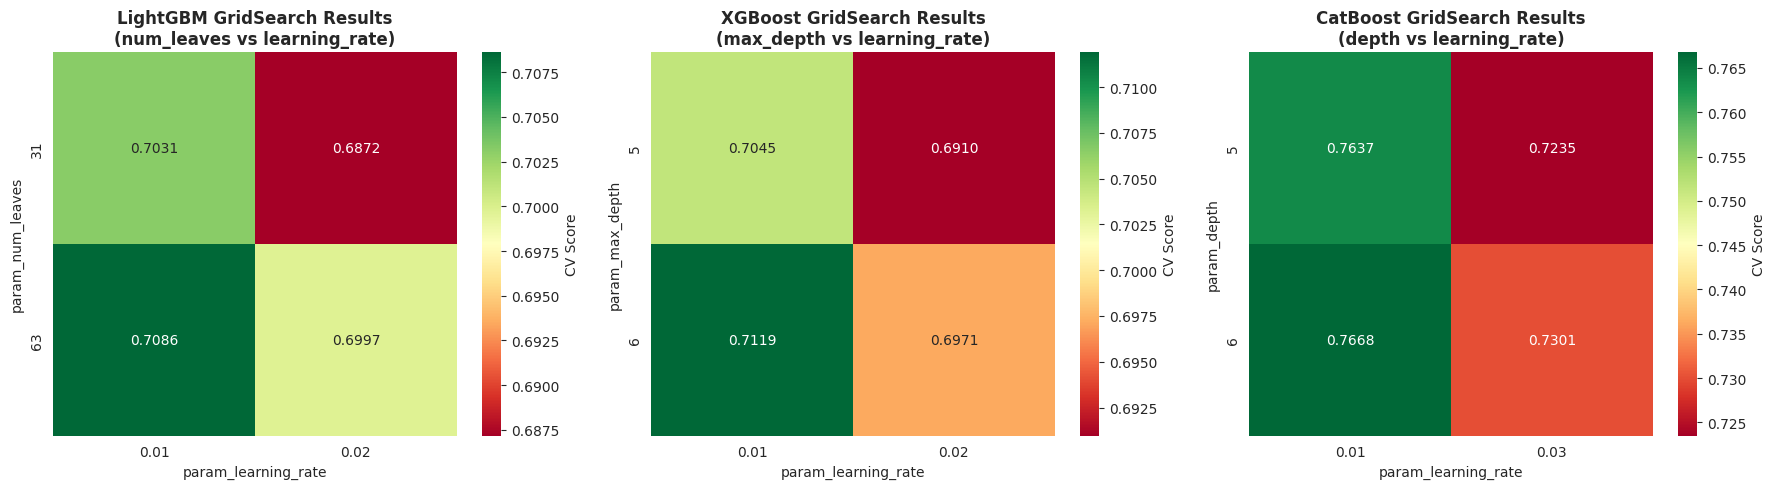

In [15]:
print("\n" + "=" * 80)
print("GRIDSEARCH RESULTS VISUALIZATION")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LightGBM GridSearchCV Results
lgb_results = pd.DataFrame(lgb_grid.cv_results_)
ax = axes[0]
pivot_lgb = lgb_results.pivot_table(values='mean_test_score',
                                    index='param_num_leaves',
                                    columns='param_learning_rate')
sns.heatmap(pivot_lgb, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax, cbar_kws={"label": "CV Score"})
ax.set_title('LightGBM GridSearch Results\n(num_leaves vs learning_rate)', fontsize=12, fontweight='bold')

# XGBoost GridSearchCV Results
xgb_results = pd.DataFrame(xgb_grid.cv_results_)
ax = axes[1]
pivot_xgb = xgb_results.pivot_table(values='mean_test_score',
                                    index='param_max_depth',
                                    columns='param_learning_rate')
sns.heatmap(pivot_xgb, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax, cbar_kws={"label": "CV Score"})
ax.set_title('XGBoost GridSearch Results\n(max_depth vs learning_rate)', fontsize=12, fontweight='bold')

# CatBoost GridSearchCV Results
cat_results = pd.DataFrame(cat_grid.cv_results_)
ax = axes[2]
pivot_cat = cat_results.pivot_table(values='mean_test_score',
                                    index='param_depth',
                                    columns='param_learning_rate')
sns.heatmap(pivot_cat, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax, cbar_kws={"label": "CV Score"})
ax.set_title('CatBoost GridSearch Results\n(depth vs learning_rate)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Section 6: Evaluations

### Round 1 - Base Models (5-Fold CV × 3 Seeds × 3 Boosters)

In [16]:
print("\n" + "=" * 80)
print("ROUND 1: TRAINING 135 BASE MODELS (5-fold CV × 3 seeds × 3 boosters)")
print("=" * 80)

SEEDS = [42, 123, 456]
N_FOLDS = 5
MODELS = ['LightGBM', 'XGBoost', 'CatBoost']

oof_predictions_r1 = np.zeros(len(X_train_full))
oof_predictions_per_model = {}
test_predictions_r1 = {}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for model_name in MODELS:
    print(f"\n--- Training {model_name} ---")
    oof_preds = np.zeros(len(X_train_full))
    test_preds = np.zeros((len(X_test), 3))

    for seed_idx, seed in enumerate(SEEDS):
        print(f"  Seed {seed_idx + 1}/3 (seed={seed})")

        fold_preds = np.zeros(len(X_train_full))
        fold_test_preds = np.zeros(len(X_test))

        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
            X_fold_train = X_train_full.iloc[train_idx][feature_cols]
            X_fold_val = X_train_full.iloc[val_idx][feature_cols]
            y_fold_train = y_train_full[train_idx]

            if model_name == 'LightGBM':
                params = lgb_grid.best_params_.copy()
                params['random_state'] = seed
                model = lgb.LGBMClassifier(**params)
                model.fit(X_fold_train, y_fold_train)

            elif model_name == 'XGBoost':
                params = xgb_grid.best_params_.copy()
                params['random_state'] = seed
                model = xgb.XGBClassifier(**params)
                model.fit(X_fold_train, y_fold_train, verbose=False)

            else:  # CatBoost
                params = cat_grid.best_params_.copy()
                params['random_seed'] = seed
                model = CatBoostClassifier(**params)
                model.fit(X_fold_train, y_fold_train, verbose=False)

            fold_preds[val_idx] = model.predict_proba(X_fold_val)[:, 1]
            fold_test_preds += model.predict_proba(X_test[feature_cols])[:, 1]

        oof_preds += fold_preds / 3
        test_preds[:, seed_idx] = fold_test_preds / N_FOLDS

    oof_predictions_per_model[model_name] = oof_preds
    test_predictions_r1[model_name] = test_preds.mean(axis=1)

for model_name in MODELS:
    oof_predictions_r1 += oof_predictions_per_model[model_name] / 3

print("\n" + "=" * 80)
print("ROUND 1 EVALUATION")
print("=" * 80)

# Evaluate each model
r1_results = []
for model_name in MODELS:
    y_pred = (oof_predictions_per_model[model_name] > 0.5).astype(int)
    acc = accuracy_score(y_train_full, y_pred)
    prec = precision_score(y_train_full, y_pred)
    rec = recall_score(y_train_full, y_pred)
    f1 = f1_score(y_train_full, y_pred)
    auc = roc_auc_score(y_train_full, oof_predictions_per_model[model_name])

    r1_results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc
    })

    print(f"\n{model_name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC:       {auc:.4f}")

# Round 1 ensemble
y_pred_r1 = (oof_predictions_r1 > 0.5).astype(int)
acc_r1 = accuracy_score(y_train_full, y_pred_r1)
auc_r1 = roc_auc_score(y_train_full, oof_predictions_r1)

r1_results.append({
    'Model': 'R1 Ensemble (Avg)',
    'Accuracy': acc_r1,
    'Precision': precision_score(y_train_full, y_pred_r1),
    'Recall': recall_score(y_train_full, y_pred_r1),
    'F1-Score': f1_score(y_train_full, y_pred_r1),
    'AUC': auc_r1
})

r1_df = pd.DataFrame(r1_results)
print(f"\nRound 1 Ensemble (Average):")
print(f"  Accuracy: {acc_r1:.4f}, AUC: {auc_r1:.4f}")


ROUND 1: TRAINING 135 BASE MODELS (5-fold CV × 3 seeds × 3 boosters)

--- Training LightGBM ---
  Seed 1/3 (seed=42)
  Seed 2/3 (seed=123)
  Seed 3/3 (seed=456)

--- Training XGBoost ---
  Seed 1/3 (seed=42)
  Seed 2/3 (seed=123)
  Seed 3/3 (seed=456)

--- Training CatBoost ---
  Seed 1/3 (seed=42)
  Seed 2/3 (seed=123)
  Seed 3/3 (seed=456)

ROUND 1 EVALUATION

LightGBM:
  Accuracy:  0.8040
  Precision: 0.8076
  Recall:    0.8017
  F1-Score:  0.8047
  AUC:       0.8969

XGBoost:
  Accuracy:  0.7998
  Precision: 0.7843
  Recall:    0.8312
  F1-Score:  0.8071
  AUC:       0.8947

CatBoost:
  Accuracy:  0.8059
  Precision: 0.7848
  Recall:    0.8470
  F1-Score:  0.8147
  AUC:       0.9009

Round 1 Ensemble (Average):
  Accuracy: 0.8065, AUC: 0.9011


#### Round 1 - Results Visualizations

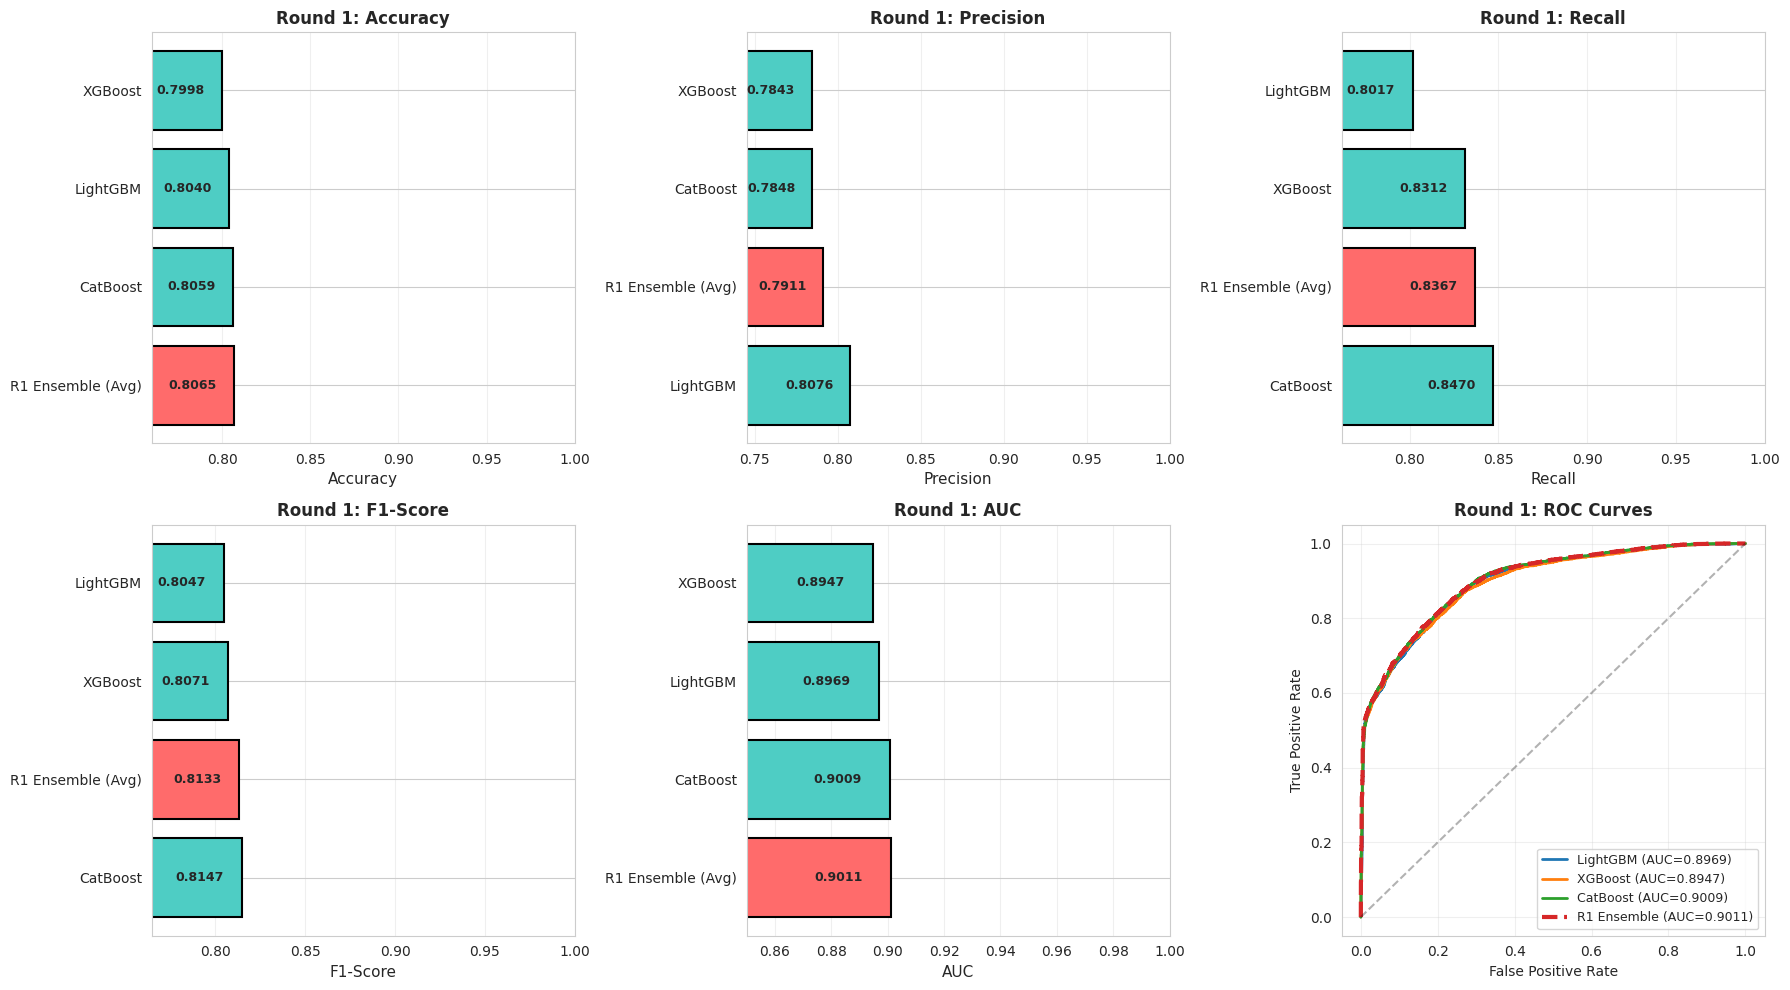

In [17]:
from sklearn.metrics import auc as calculate_auc # Re-import auc with an alias to avoid name collision

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]

    data = r1_df.sort_values(metric, ascending=False)
    colors = ['#FF6B6B' if 'Avg' in m else '#4ECDC4' for m in data['Model']]

    ax.barh(data['Model'], data[metric], color=colors, edgecolor='black', linewidth=1.5)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(f'Round 1: {metric}', fontsize=12, fontweight='bold')
    ax.set_xlim([min(data[metric]) * 0.95, 1.0])

    for i, v in enumerate(data[metric]):
        ax.text(v - 0.01, i, f'{v:.4f}', ha='right', va='center', fontweight='bold', fontsize=9)

    ax.grid(axis='x', alpha=0.3)

# ROC curves for each model
ax = axes[1, 2]
for model_name in MODELS:
    fpr, tpr, _ = roc_curve(y_train_full, oof_predictions_per_model[model_name])
    auc_score = calculate_auc(fpr, tpr) # Use the aliased function
    ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc_score:.4f})', linewidth=2)

# R1 Ensemble
fpr_r1, tpr_r1, _ = roc_curve(y_train_full, oof_predictions_r1)
auc_r1_plot = calculate_auc(fpr_r1, tpr_r1) # Use the aliased function
ax.plot(fpr_r1, tpr_r1, label=f'R1 Ensemble (AUC={auc_r1_plot:.4f})', linewidth=3, linestyle='--')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Round 1: ROC Curves', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Stacking with Logistic Regression


STACKING WITH LOGISTIC REGRESSION (Meta-learner)

Stacked LR Meta-learner:
  Accuracy: 0.8051, AUC: 0.9018
  Coefficients: LGB=3.2438, XGB=0.8310, CAT=3.5931
  Intercept: -3.7973


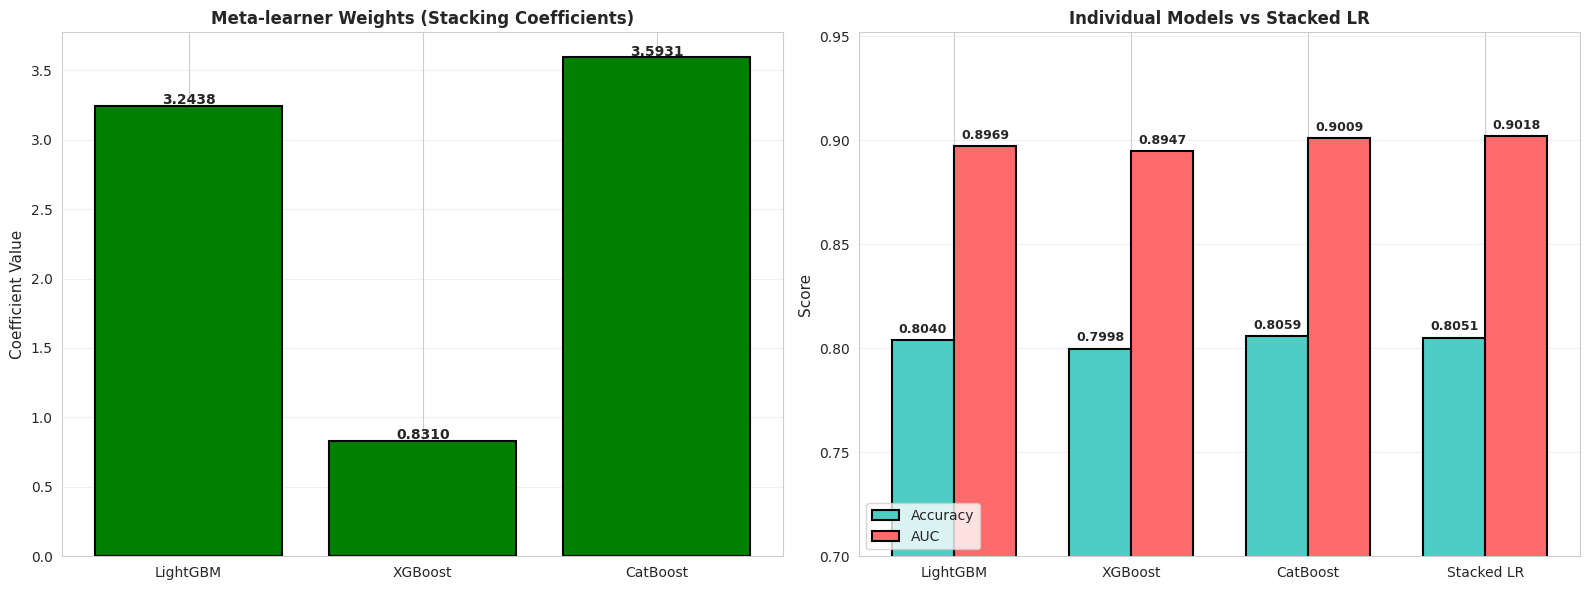

In [18]:
print("\n" + "=" * 80)
print("STACKING WITH LOGISTIC REGRESSION (Meta-learner)")
print("=" * 80)

X_meta = np.column_stack([oof_predictions_per_model[m] for m in MODELS])
X_meta_test = np.column_stack([test_predictions_r1[m] for m in MODELS])

meta_learner = LogisticRegression(max_iter=1000, random_state=42)
meta_learner.fit(X_meta, y_train_full)

oof_predictions_stacked = meta_learner.predict_proba(X_meta)[:, 1]
y_pred_stacked = (oof_predictions_stacked > 0.5).astype(int)

acc_stacked = accuracy_score(y_train_full, y_pred_stacked)
auc_stacked = roc_auc_score(y_train_full, oof_predictions_stacked)

print(f"\nStacked LR Meta-learner:")
print(f"  Accuracy: {acc_stacked:.4f}, AUC: {auc_stacked:.4f}")
print(f"  Coefficients: LGB={meta_learner.coef_[0][0]:.4f}, XGB={meta_learner.coef_[0][1]:.4f}, CAT={meta_learner.coef_[0][2]:.4f}")
print(f"  Intercept: {meta_learner.intercept_[0]:.4f}")

test_predictions_stacked = meta_learner.predict_proba(X_meta_test)[:, 1]

# Visualization of stacking
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coefficient importance
ax = axes[0]
coeffs = meta_learner.coef_[0]
colors_coeff = ['green' if x > 0 else 'red' for x in coeffs]
ax.bar(MODELS, coeffs, color=colors_coeff, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Coefficient Value', fontsize=11)
ax.set_title('Meta-learner Weights (Stacking Coefficients)', fontsize=12, fontweight='bold')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(coeffs):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Stacking vs individual models comparison
ax = axes[1]
stacking_results = pd.DataFrame({
    'Model': MODELS + ['Stacked LR'],
    'Accuracy': [accuracy_score(y_train_full, (oof_predictions_per_model[m] > 0.5).astype(int)) for m in MODELS] + [acc_stacked],
    'AUC': [roc_auc_score(y_train_full, oof_predictions_per_model[m]) for m in MODELS] + [auc_stacked]
})

x = np.arange(len(stacking_results))
width = 0.35

bars1 = ax.bar(x - width/2, stacking_results['Accuracy'], width, label='Accuracy', color='#4ECDC4', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, stacking_results['AUC'], width, label='AUC', color='#FF6B6B', edgecolor='black', linewidth=1.5)

ax.set_ylabel('Score', fontsize=11)
ax.set_title('Individual Models vs Stacked LR', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(stacking_results['Model'])
ax.legend(loc='lower left')

# Fix: Increase y-limit slightly more to prevent label overflow and ensure space for text
max_val = stacking_results[['Accuracy', 'AUC']].max().max()
ax.set_ylim([0.70, max_val + 0.05])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Round 2 - Pseudo-Labeling and Training


PSEUDO-LABELING & ROUND 2 TRAINING

Confident Predictions (threshold=0.92):
  High confidence samples: 1522 / 4277 (35.59%)
  Pseudo-labeled as Transported: 1051
  Pseudo-labeled as Not Transported: 471

Augmented Training Set:
  Original samples: 8693
  Pseudo-labeled samples: 1522
  Total: 10215 (17.5% increase)


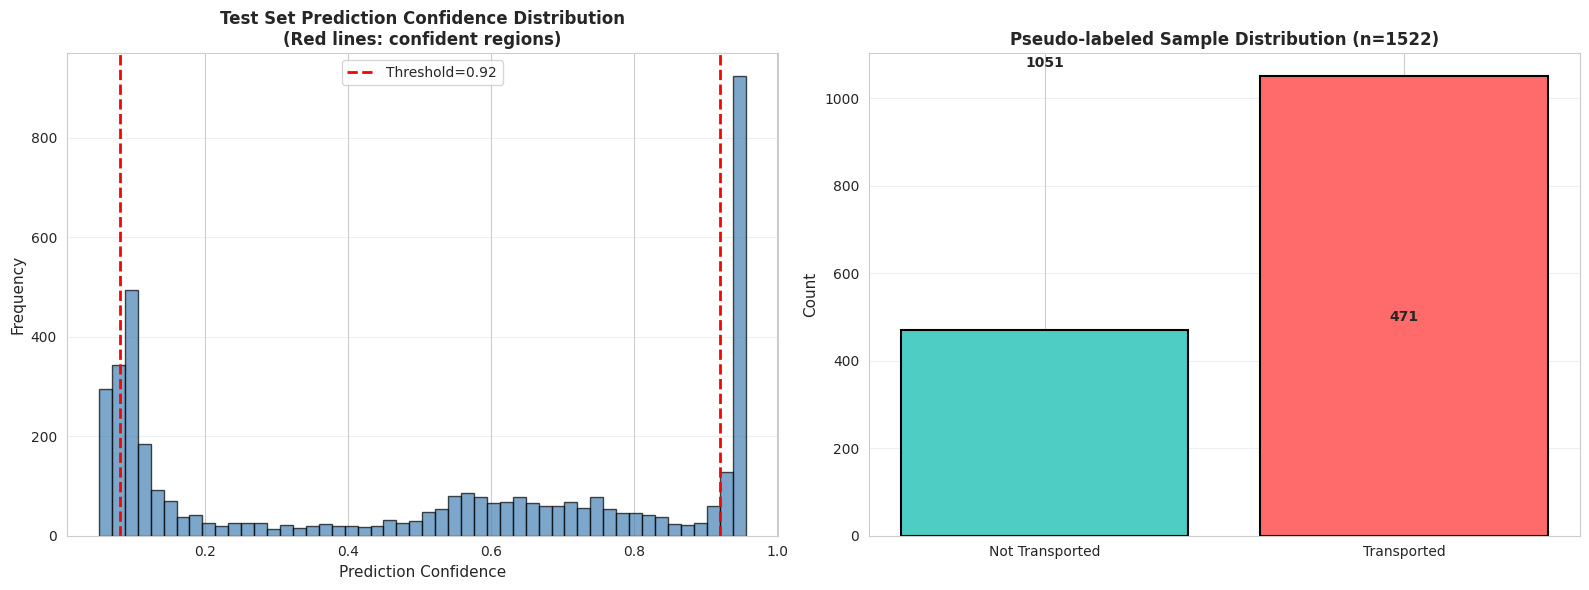


--- Round 2: Training on augmented dataset ---
  LightGBM... Done!
  XGBoost... Done!
  CatBoost... Done!

Round 2 Results (on original training set):
  Accuracy: 0.8311, AUC: 0.9267


In [19]:
print("\n" + "=" * 80)
print("PSEUDO-LABELING & ROUND 2 TRAINING")
print("=" * 80)

CONFIDENCE_THRESHOLD = 0.92
confident_mask = (test_predictions_stacked > CONFIDENCE_THRESHOLD) | (test_predictions_stacked < (1 - CONFIDENCE_THRESHOLD))

pseudo_labels = (test_predictions_stacked > 0.5).astype(int)
n_pseudo = confident_mask.sum()

print(f"\nConfident Predictions (threshold={CONFIDENCE_THRESHOLD}):")
print(f"  High confidence samples: {n_pseudo} / {len(X_test)} ({100 * n_pseudo / len(X_test):.2f}%)")
print(f"  Pseudo-labeled as Transported: {pseudo_labels[confident_mask].sum()}")
print(f"  Pseudo-labeled as Not Transported: {n_pseudo - pseudo_labels[confident_mask].sum()}")

# Create augmented training set
X_train_pseudo = pd.concat([
    X_train_full[feature_cols],
    X_test[feature_cols].iloc[confident_mask]
], ignore_index=True)

y_train_pseudo = np.concatenate([
    y_train_full,
    pseudo_labels[confident_mask]
])

print(f"\nAugmented Training Set:")
print(f"  Original samples: {len(X_train_full)}")
print(f"  Pseudo-labeled samples: {n_pseudo}")
print(f"  Total: {len(X_train_pseudo)} ({100 * n_pseudo / len(X_train_full):.1f}% increase)")

# Visualize pseudo-labeling
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confidence score distribution
ax = axes[0]
ax.hist(test_predictions_stacked, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(CONFIDENCE_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold={CONFIDENCE_THRESHOLD}')
ax.axvline(1 - CONFIDENCE_THRESHOLD, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Prediction Confidence', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Test Set Prediction Confidence Distribution\n(Red lines: confident regions)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Pseudo-label distribution
ax = axes[1]
pseudo_counts = pd.Series(pseudo_labels[confident_mask]).value_counts()
colors_pseudo = ['#4ECDC4', '#FF6B6B']
ax.bar(['Not Transported', 'Transported'],
       [pseudo_counts[0] if 0 in pseudo_counts.index else 0,
        pseudo_counts[1] if 1 in pseudo_counts.index else 0],
       color=colors_pseudo, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Count', fontsize=11)
ax.set_title(f'Pseudo-labeled Sample Distribution (n={n_pseudo})', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(pseudo_counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Train Round 2 models
oof_predictions_r2 = np.zeros(len(X_train_full))
test_predictions_r2 = {}

print("\n--- Round 2: Training on augmented dataset ---")

for model_name in MODELS:
    print(f"  {model_name}...", end=' ')

    if model_name == 'LightGBM':
        params = lgb_grid.best_params_.copy()
        base_model = lgb.LGBMClassifier(**params)
        base_model.fit(X_train_pseudo, y_train_pseudo)
    elif model_name == 'XGBoost':
        params = xgb_grid.best_params_.copy()
        base_model = xgb.XGBClassifier(**params)
        base_model.fit(X_train_pseudo, y_train_pseudo, verbose=False)
    else: # CatBoost
        params = cat_grid.best_params_.copy()
        base_model = CatBoostClassifier(**params)
        base_model.fit(X_train_pseudo, y_train_pseudo, verbose=False)

    oof_preds_r2 = base_model.predict_proba(X_train_full[feature_cols])[:, 1]
    oof_predictions_r2 += oof_preds_r2 / 3

    test_predictions_r2[model_name] = base_model.predict_proba(X_test[feature_cols])[:, 1]

    print("Done!")

test_predictions_r2_avg = np.mean([test_predictions_r2[m] for m in MODELS], axis=0)

# Evaluate Round 2
y_pred_r2 = (oof_predictions_r2 > 0.5).astype(int)
acc_r2 = accuracy_score(y_train_full, y_pred_r2)
auc_r2 = roc_auc_score(y_train_full, oof_predictions_r2)

print(f"\nRound 2 Results (on original training set):")
print(f"  Accuracy: {acc_r2:.4f}, AUC: {auc_r2:.4f}")

### Blending Round 1 and Round 2


BLENDING ROUND 1 & ROUND 2

Blending Weight Search Results:
 R1 Weight  R2 Weight  Accuracy      AUC
      0.00       1.00  0.831128 0.926677
      0.05       0.95  0.828598 0.925061
      0.10       0.90  0.826872 0.923512
      0.15       0.85  0.825147 0.922040
      0.20       0.80  0.823651 0.920626
      0.25       0.75  0.821005 0.919251
      0.30       0.70  0.819050 0.917923
      0.35       0.65  0.817324 0.916630
      0.40       0.60  0.815944 0.915406
      0.45       0.55  0.814909 0.914200
      0.50       0.50  0.813758 0.913035
      0.55       0.45  0.812263 0.911897
      0.60       0.40  0.811342 0.910774
      0.65       0.35  0.810767 0.909663
      0.70       0.30  0.809502 0.908568
      0.75       0.25  0.809042 0.907480
      0.80       0.20  0.807891 0.906395
      0.85       0.15  0.806971 0.905281
      0.90       0.10  0.806511 0.904150
      0.95       0.05  0.805591 0.902979
      1.00       0.00  0.805131 0.901776

Optimal blend: R1=0.00, R2=1.00
Best

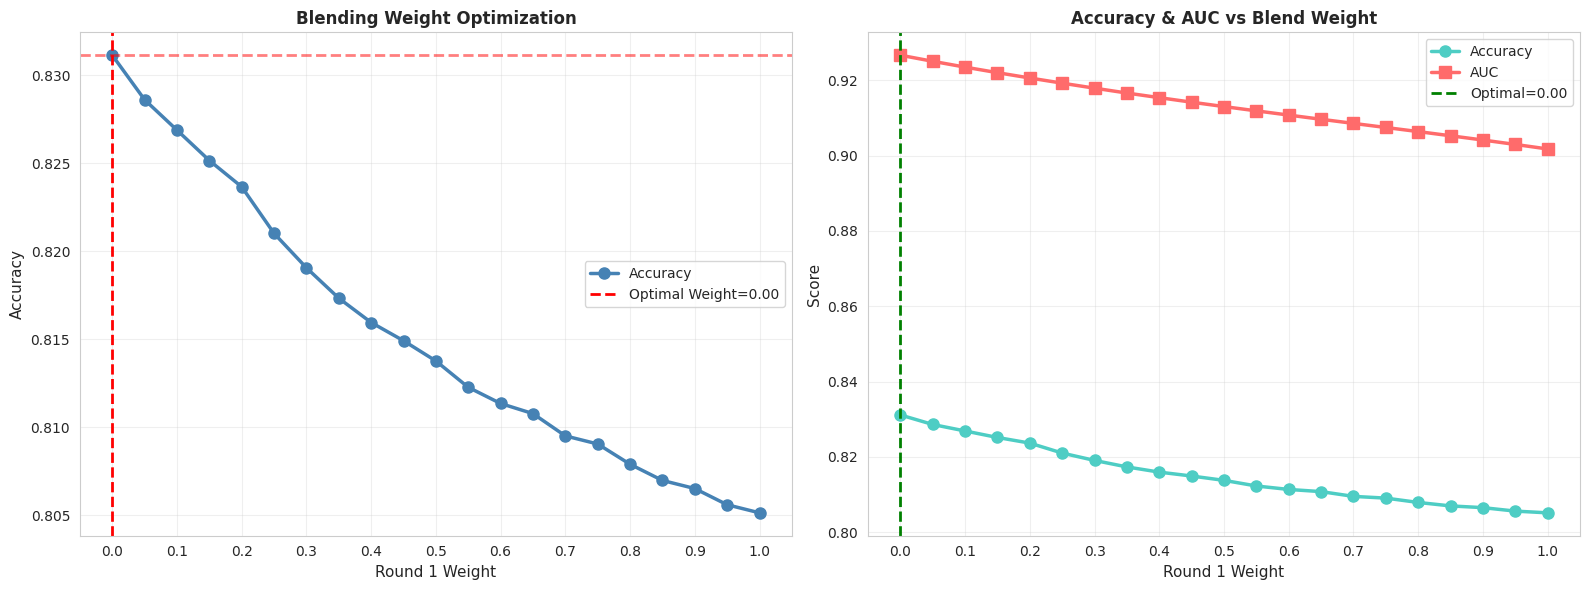

In [20]:
print("\n" + "=" * 80)
print("BLENDING ROUND 1 & ROUND 2")
print("=" * 80)

best_blend_weight = 0.5
best_blend_acc = 0
blend_results = []

for alpha in np.arange(0, 1.01, 0.05):
    oof_blended = alpha * oof_predictions_stacked + (1 - alpha) * oof_predictions_r2
    y_pred_blended = (oof_blended > 0.5).astype(int)
    acc = accuracy_score(y_train_full, y_pred_blended)

    blend_results.append({
        'R1 Weight': alpha,
        'R2 Weight': 1 - alpha,
        'Accuracy': acc,
        'AUC': roc_auc_score(y_train_full, oof_blended)
    })

    if acc > best_blend_acc:
        best_blend_acc = acc
        best_blend_weight = alpha

blend_df = pd.DataFrame(blend_results)
print("\nBlending Weight Search Results:")
print(blend_df.to_string(index=False))

print(f"\nOptimal blend: R1={best_blend_weight:.2f}, R2={1-best_blend_weight:.2f}")
print(f"Best blended accuracy: {best_blend_acc:.4f}")

# Visualization of blending
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy vs blend weight
ax = axes[0]
ax.plot(blend_df['R1 Weight'], blend_df['Accuracy'], marker='o', linewidth=2.5,
        markersize=8, color='steelblue', label='Accuracy')
ax.axvline(best_blend_weight, color='red', linestyle='--', linewidth=2,
          label=f'Optimal Weight={best_blend_weight:.2f}')
ax.axhline(best_blend_acc, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax.set_xlabel('Round 1 Weight', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Blending Weight Optimization', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xticks(np.arange(0, 1.1, 0.1))

# Both Accuracy and AUC
ax = axes[1]
ax.plot(blend_df['R1 Weight'], blend_df['Accuracy'], marker='o', linewidth=2.5,
        markersize=8, color='#4ECDC4', label='Accuracy')
ax.plot(blend_df['R1 Weight'], blend_df['AUC'], marker='s', linewidth=2.5,
        markersize=8, color='#FF6B6B', label='AUC')
ax.axvline(best_blend_weight, color='green', linestyle='--', linewidth=2,
          label=f'Optimal={best_blend_weight:.2f}')
ax.set_xlabel('Round 1 Weight', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Accuracy & AUC vs Blend Weight', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xticks(np.arange(0, 1.1, 0.1))

plt.tight_layout()
plt.show()

### Threshold Tuning


THRESHOLD TUNING FOR FINAL PREDICTIONS

Threshold Tuning Results (Top 10 by F1-Score):
 Threshold  Accuracy  Precision   Recall       F1
      0.52  0.838491   0.834157 0.847876 0.840961
      0.51  0.834580   0.821382 0.858154 0.839366
      0.53  0.839066   0.848911 0.827775 0.838210
      0.54  0.842862   0.870936 0.807675 0.838113
      0.50  0.831128   0.810765 0.867063 0.837969
      0.48  0.826642   0.796163 0.881453 0.836640
      0.47  0.824687   0.788633 0.890589 0.836516
      0.49  0.827677   0.801508 0.874372 0.836356
      0.46  0.822731   0.783417 0.895614 0.835767
      0.41  0.818130   0.769824 0.911375 0.834641

Optimal threshold (F1-based): 0.52


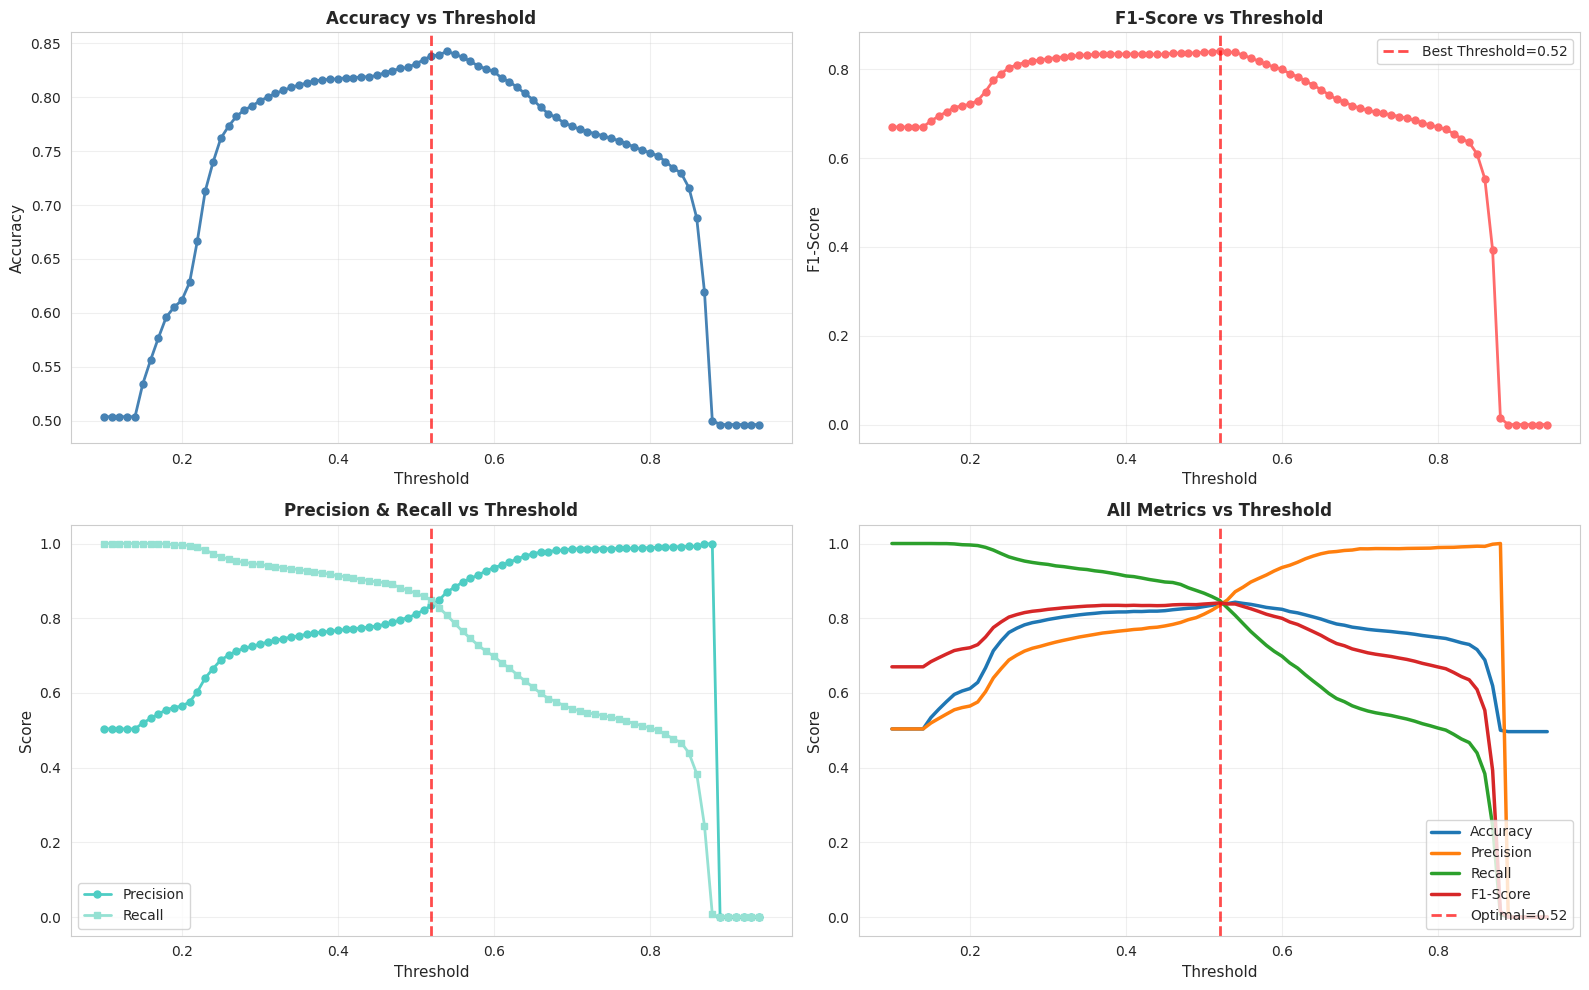

In [21]:
print("\n" + "=" * 80)
print("THRESHOLD TUNING FOR FINAL PREDICTIONS")
print("=" * 80)

oof_final = best_blend_weight * oof_predictions_stacked + (1 - best_blend_weight) * oof_predictions_r2
test_final = best_blend_weight * test_predictions_stacked + (1 - best_blend_weight) * test_predictions_r2_avg

thresholds = np.arange(0.1, 0.95, 0.01)
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (oof_final > threshold).astype(int)
    f1 = f1_score(y_train_full, y_pred_threshold)
    acc = accuracy_score(y_train_full, y_pred_threshold)
    prec = precision_score(y_train_full, y_pred_threshold, zero_division=0)
    rec = recall_score(y_train_full, y_pred_threshold, zero_division=0)

    threshold_results.append({
        'Threshold': threshold,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    })

threshold_df = pd.DataFrame(threshold_results)
best_threshold = threshold_df.loc[threshold_df['F1'].idxmax(), 'Threshold']

print("\nThreshold Tuning Results (Top 10 by F1-Score):")
print(threshold_df.sort_values('F1', ascending=False).head(10).to_string(index=False))

print(f"\nOptimal threshold (F1-based): {best_threshold:.2f}")

# Visualization of threshold tuning
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Accuracy vs Threshold
ax = axes[0, 0]
ax.plot(threshold_df['Threshold'], threshold_df['Accuracy'], marker='o', linewidth=2,
        color='steelblue', markersize=5)
ax.axvline(best_threshold, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy vs Threshold', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# F1-Score vs Threshold
ax = axes[0, 1]
ax.plot(threshold_df['Threshold'], threshold_df['F1'], marker='o', linewidth=2,
        color='#FF6B6B', markersize=5)
ax.axvline(best_threshold, color='red', linestyle='--', linewidth=2,
          label=f'Best Threshold={best_threshold:.2f}', alpha=0.7)
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_title('F1-Score vs Threshold', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Precision & Recall vs Threshold
ax = axes[1, 0]
ax.plot(threshold_df['Threshold'], threshold_df['Precision'], marker='o', linewidth=2,
        color='#4ECDC4', markersize=5, label='Precision')
ax.plot(threshold_df['Threshold'], threshold_df['Recall'], marker='s', linewidth=2,
        color='#95E1D3', markersize=5, label='Recall')
ax.axvline(best_threshold, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision & Recall vs Threshold', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# All metrics together
ax = axes[1, 1]
ax.plot(threshold_df['Threshold'], threshold_df['Accuracy'], linewidth=2.5, label='Accuracy')
ax.plot(threshold_df['Threshold'], threshold_df['Precision'], linewidth=2.5, label='Precision')
ax.plot(threshold_df['Threshold'], threshold_df['Recall'], linewidth=2.5, label='Recall')
ax.plot(threshold_df['Threshold'], threshold_df['F1'], linewidth=2.5, label='F1-Score')
ax.axvline(best_threshold, color='red', linestyle='--', linewidth=2,
          label=f'Optimal={best_threshold:.2f}', alpha=0.7)
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('All Metrics vs Threshold', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7: Final Evaluation


FINAL EVALUATION

Final Out-of-Fold Metrics:
  Accuracy:  0.8385
  F1-Score:  0.8410
  AUC Score: 0.9267


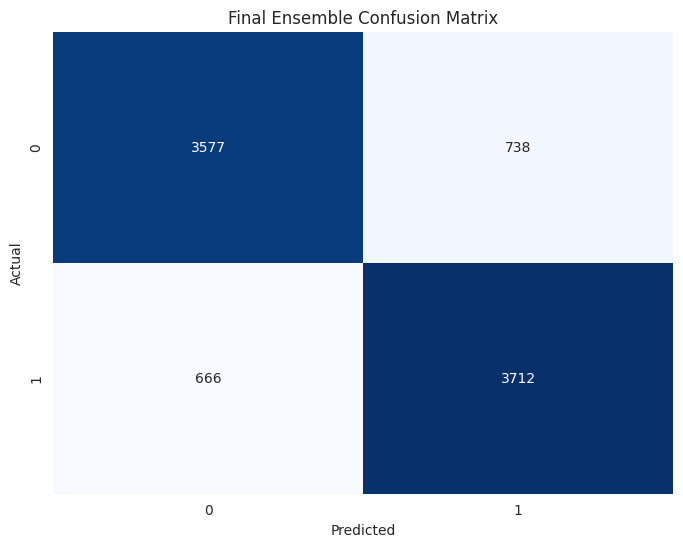


Submission file 'submission.csv' has been created successfully!
Submission file saved to Drive as: submission_20260606_0156.csv


,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [ ]:
import shutil
from datetime import datetime

print("\n" + "=" * 80)
print("FINAL EVALUATION")
print("=" * 80)

# Calculate final predictions using optimal threshold
y_pred_final = (oof_final > best_threshold).astype(int)

# Compute metrics
final_acc = accuracy_score(y_train_full, y_pred_final)
final_f1 = f1_score(y_train_full, y_pred_final)
final_auc = roc_auc_score(y_train_full, oof_final)

print(f"\nFinal Out-of-Fold Metrics:")
print(f"  Accuracy:  {final_acc:.4f}")
print(f"  F1-Score:  {final_f1:.4f}")
print(f"  AUC Score: {final_auc:.4f}")

# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_train_full, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Ensemble Confusion Matrix')
plt.show()

# Generate Submission File
test_preds_final = (test_final > best_threshold).astype(bool)

submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Transported': test_preds_final
})

# Local save
submission.to_csv('submission.csv', index=False)
print("\nSubmission file 'submission.csv' has been created successfully!")

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
versioned_filename = f"submission_{timestamp}.csv"
shutil.copy('submission.csv', os.path.join("./", versioned_filename))

print(f"Submission file saved to Drive as: {versioned_filename}")
display(submission.head())